# Unzip dataset

In [2]:
!unzip '/content/mango_leaf-8-class.zip'

Archive:  /content/mango_leaf-8-class.zip
   creating: mango_leaf/New folder/
   creating: mango_leaf/New folder/Anthracnose/
  inflating: mango_leaf/New folder/Anthracnose/20211008_124249 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124250 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124252 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124253 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124256 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124301 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124302 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124305 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124306 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124310 (Custom).jpg  
  inflating: mango_leaf/New folder/Anthracnose/20211008_124312 (Custom).jpg  
  inflating: man

# import library

In [3]:
import os
import shutil
import random

import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# Import Data Science Libraries
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import itertools
import random

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
import skimage
from skimage.transform import resize
# label binarizer
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

# Mobile Net

## Split data into main and test validation

In [4]:
from ast import main
# Define your dataset directories and the directories where you want to create the splits:

dataset_dir = "/content/mango_leaf/New folder"  # Replace with the path to your dataset
main_dir = "train_set"
test_dir = "test_set"

# Create the train, test, and validation directories if they don't exist
os.makedirs(main_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [5]:
# Set the split ratio (for main 80% , for test 20%)

main_ratio = 0.80
test_ratio = 0.20

In [6]:
# iterate throught the folders containing our two type of data and splite them into main and test

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)

    if os.path.isdir(class_path):
        file_list = os.listdir(class_path)
        random.shuffle(file_list)

        main_split = int(len(file_list) * main_ratio)
        test_split = int(len(file_list) * (main_ratio + test_ratio))

        main_files = file_list[:main_split]
        test_files = file_list[main_split:test_split]


        for file_name in main_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(main_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)

        for file_name in test_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(test_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)



## run

In [7]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 32
image_size = (224, 224)
epochs = 30

In [8]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 2560 images belonging to 8 classes.
Found 640 images belonging to 8 classes.


In [9]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 800 images belonging to 8 classes.


# mobilenetv2

In [ ]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.6463 - loss: 5.7454 - val_accuracy: 0.8828 - val_loss: 0.3846
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.8921 - loss: 0.3279 - val_accuracy: 0.9062 - val_loss: 0.2727
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.9403 - loss: 0.2592 - val_accuracy: 0.9297 - val_loss: 0.2495
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step - accuracy: 0.9412 - loss: 0.1971 - val_accuracy: 0.9625 - val_loss: 0.1613
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.9433 - loss: 0.2068 - val_accuracy: 0.9422 - val_loss: 0.2070
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9408 - loss: 0.1926 - val_accuracy: 0.9109 - val_loss: 0.3426
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.9425 - loss: 0.2258 - val_accuracy: 0.9375 - val_loss: 0.2998
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.9505 - loss: 0.1439 - val_accuracy: 0.

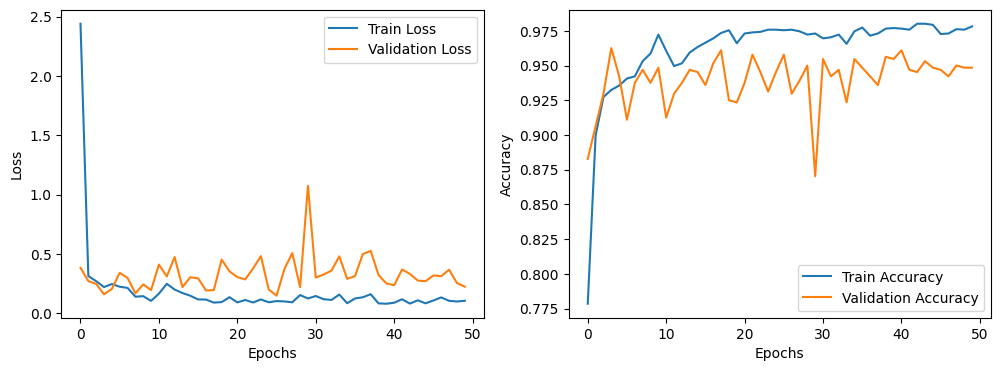

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       100
           1       0.99      1.00      1.00       100
           2       1.00      1.00      1.00       100
           3       0.99      1.00      1.00       100
           4       0.92      0.95      0.94       100
           5       0.97      0.99      0.98       100
           6       1.00      0.94      0.97       100
           7       0.95      0.97      0.96       100

    accuracy                           0.97       800
   macro avg       0.98      0.97      0.98       800
weighted avg       0.98      0.97      0.98       800



In [ ]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.975


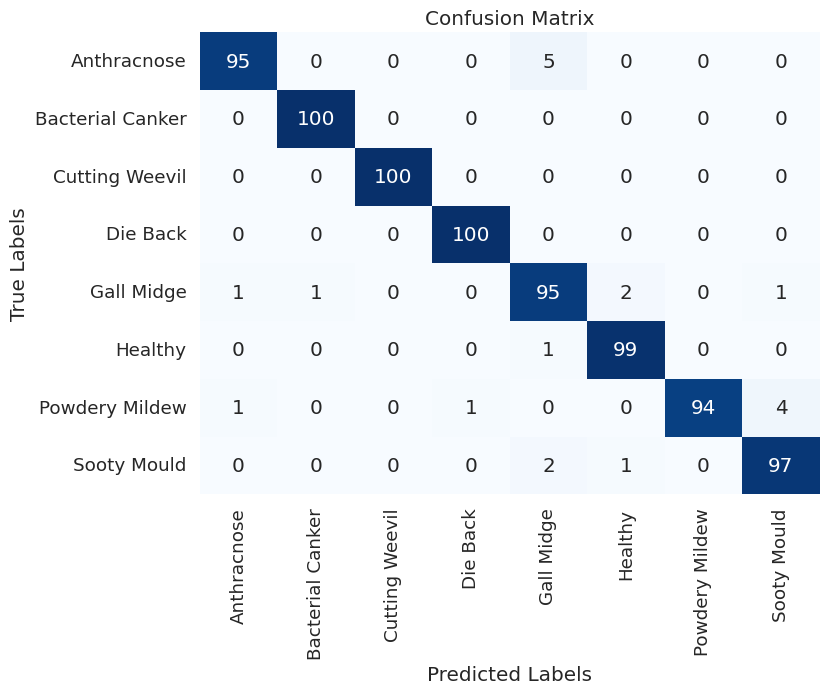

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step


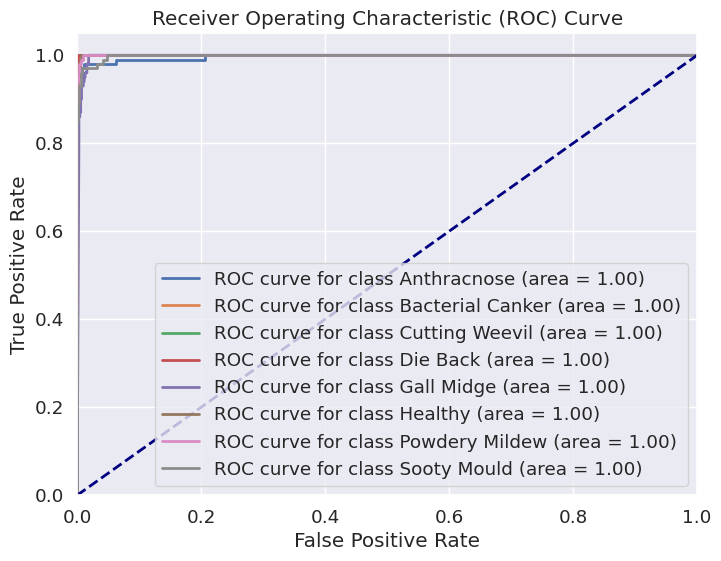

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(class_labels)):
    fpr[i], tpr[i], _ = roc_curve(y_true_m1, predictions_m1[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curve
plt.figure(figsize=(8, 6))
for i in range(len(class_labels)):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve for class {0} (area = {1:0.2f})'.format(class_labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()


In [ ]:
m1.save('model.h5')

# SDG

In [15]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = SGD(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 26s 156ms/step - accuracy: 0.5683 - loss: 1.5915 - val_accuracy: 0.9266 - val_loss: 0.2338
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.9367 - loss: 0.2048 - val_accuracy: 0.9297 - val_loss: 0.1912
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 95ms/step - accuracy: 0.9631 - loss: 0.1094 - val_accuracy: 0.9563 - val_loss: 0.1347
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.9822 - loss: 0.0725 - val_accuracy: 0.9500 - val_loss: 0.1400
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 62ms/step - accuracy: 0.9868 - loss: 0.0547 - val_accuracy: 0.9531 - val_loss: 0.1323
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - accuracy: 0.9915 - loss: 0.0410 - val_accuracy: 0.9609 - val_loss: 0.1137
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.9925 - loss: 0.0295 - val_accuracy: 0.9688 - val_loss: 0.1048
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 63ms/step - accu

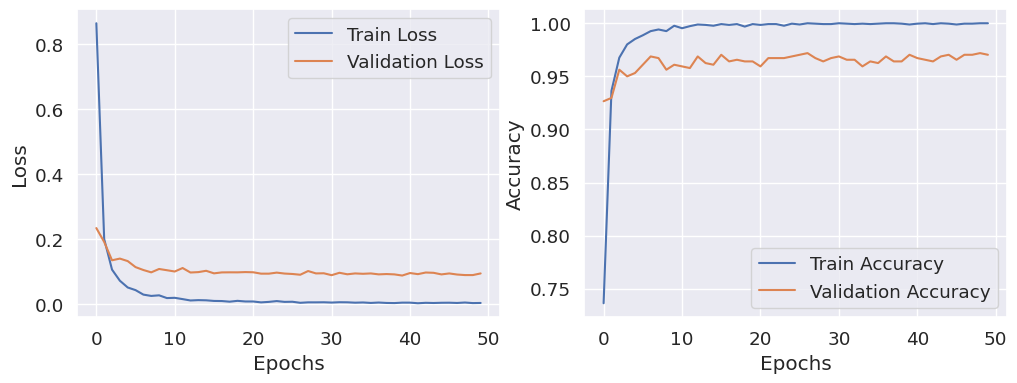

In [16]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       100
           1       0.97      0.99      0.98       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       0.94      0.95      0.95       100
           5       0.99      0.99      0.99       100
           6       1.00      0.98      0.99       100
           7       0.97      0.99      0.98       100

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800



In [18]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.98125


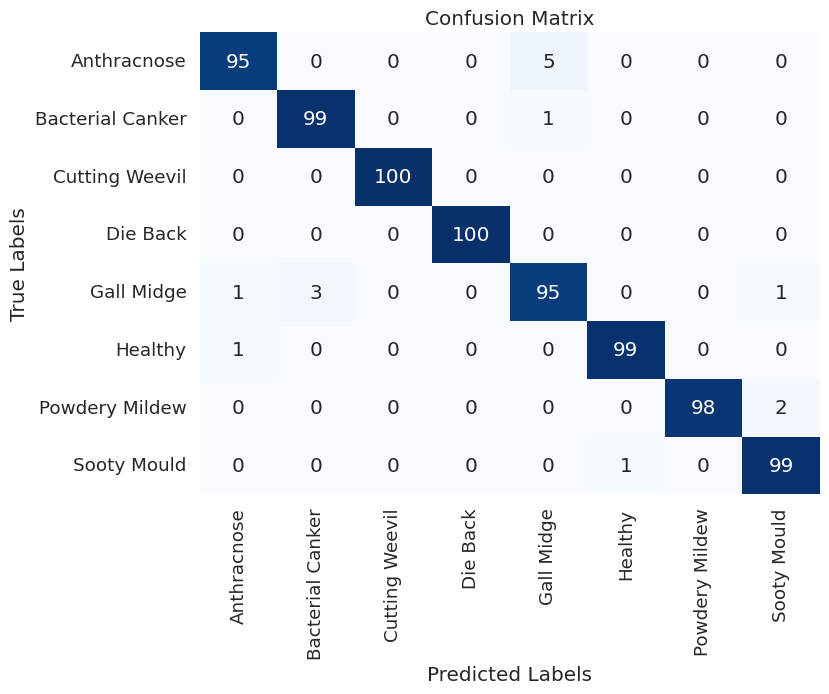

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# RMSprop

In [20]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = RMSprop(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 130ms/step - accuracy: 0.6311 - loss: 16.1934 - val_accuracy: 0.8906 - val_loss: 0.4813
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 16s 106ms/step - accuracy: 0.8894 - loss: 0.7189 - val_accuracy: 0.9297 - val_loss: 0.5117
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 9s 113ms/step - accuracy: 0.9201 - loss: 0.6038 - val_accuracy: 0.9219 - val_loss: 0.7438
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 72ms/step - accuracy: 0.9481 - loss: 0.5152 - val_accuracy: 0.9203 - val_loss: 0.5214
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9456 - loss: 0.5423 - val_accuracy: 0.9547 - val_loss: 0.3507
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9683 - loss: 0.2586 - val_accuracy: 0.9641 - val_loss: 0.2340
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.9691 - loss: 0.1989 - val_accuracy: 0.9266 - val_loss: 0.4765
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 0.9613 - loss: 0.1812 - val_accuracy: 0.9

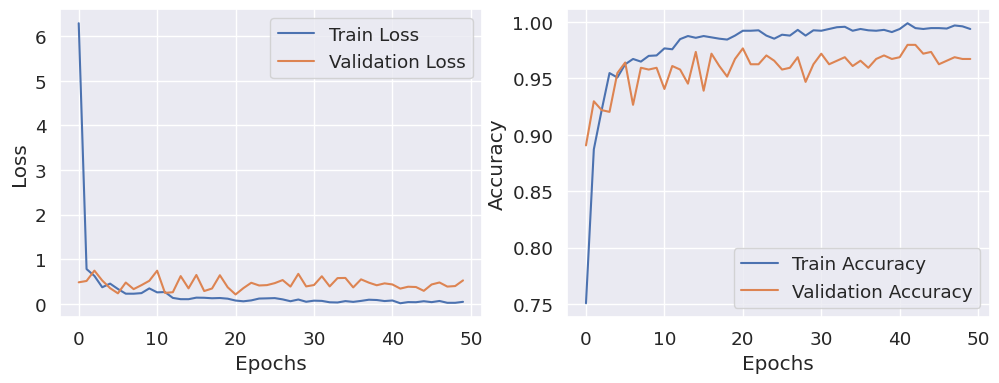

In [21]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [22]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       100
           1       0.99      0.98      0.98       100
           2       1.00      1.00      1.00       100
           3       0.99      1.00      1.00       100
           4       0.95      0.98      0.97       100
           5       1.00      1.00      1.00       100
           6       1.00      0.97      0.98       100
           7       0.97      1.00      0.99       100

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800



In [23]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.98625


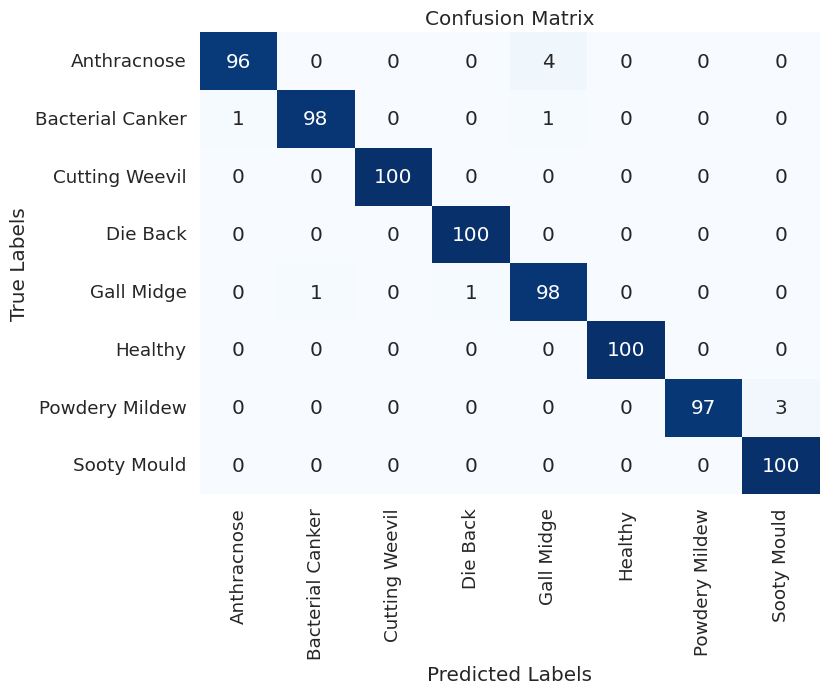

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
confusion_m1= confusion_matrix(y_true_m1, y_pred_m1)

# Define class labels (you can get them from the generator)
class_labels = list(test_generator.class_indices.keys())

# Create a heatmap
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(confusion_m1, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Nadam

In [25]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Nadam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(8, activation='softmax'))

# Compile the model
optimizer = Nadam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer,
              metrics=['accuracy'])

# Train the model
history_m1 = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 18s 114ms/step - accuracy: 0.6264 - loss: 6.1034 - val_accuracy: 0.9281 - val_loss: 0.2229
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.9162 - loss: 0.3032 - val_accuracy: 0.9422 - val_loss: 0.2279
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.9146 - loss: 0.3117 - val_accuracy: 0.9359 - val_loss: 0.2337
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.9417 - loss: 0.2444 - val_accuracy: 0.9344 - val_loss: 0.2784
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 10s 75ms/step - accuracy: 0.9372 - loss: 0.2661 - val_accuracy: 0.9391 - val_loss: 0.2483
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9496 - loss: 0.2239 - val_accuracy: 0.9297 - val_loss: 0.2407
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 11s 67ms/step - accuracy: 0.9503 - loss: 0.1605 - val_accuracy: 0.9469 - val_loss: 0.2129
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9723 - loss: 0.0958 - val_accuracy: 0.94

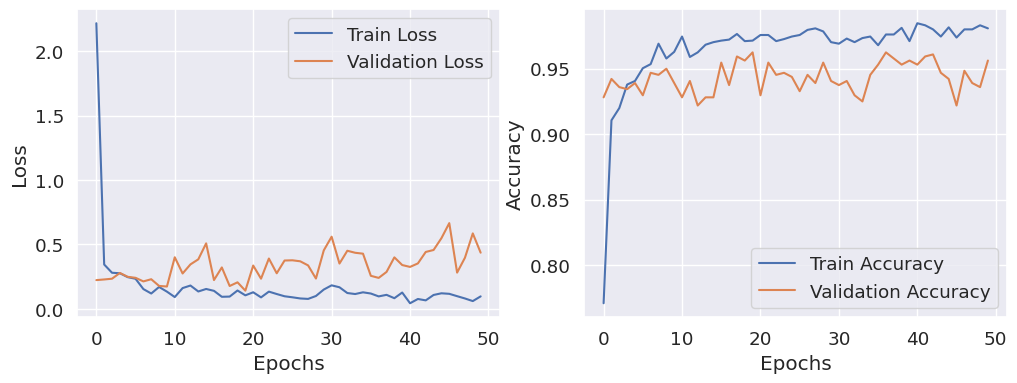

In [26]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1.history['loss'], label='Train Loss')
plt.plot(history_m1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.97      0.99      0.98       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       0.99      0.95      0.97       100
           5       1.00      0.98      0.99       100
           6       1.00      0.99      0.99       100
           7       0.96      1.00      0.98       100

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800



In [28]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.98625


In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       100
           1       0.97      0.99      0.98       100
           2       1.00      1.00      1.00       100
           3       1.00      1.00      1.00       100
           4       0.99      0.95      0.97       100
           5       1.00      0.98      0.99       100
           6       1.00      0.99      0.99       100
           7       0.96      1.00      0.98       100

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800

